# 2-Neuron Attractor RNN Demo
### CogSci 131 — Lecture 24: Working Memory & RNNs

This notebook demonstrates how a simple 2-neuron recurrent network produces **attractor dynamics** — persistent activity states that can serve as a neural substrate for working memory.

**The model:**

Each neuron's firing rate $r_i$ evolves according to:

$$\tau \frac{dr}{dt} = -r + \tanh(Wr)$$

- $W$ is the weight matrix (recurrent connections between the two neurons)
- The $-r$ term is a leak — without input, activity decays
- The $\tanh(Wr)$ term is the recurrent drive
- **Fixed points** are states where $\dot{r} = 0$: the network doesn't move

**Try tweaking:**
- `w_self`: self-excitation (diagonal of W) — how strongly each neuron excites itself
- `w_cross`: cross-inhibition (off-diagonal) — how strongly each neuron inhibits the other
- `tau`: time constant — how fast the network evolves

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.lines import Line2D

# ─────────────────────────────────────────
#  TWEAK THESE to explore attractor dynamics
# ─────────────────────────────────────────
w_self  =  1.8   # self-excitation  (try: 1.0, 1.5, 2.5)
w_cross = -0.5   # cross-inhibition (try: 0.0, -1.0, +0.5)
tau     =  1.0   # time constant

W = np.array([[w_self,  w_cross],
              [w_cross, w_self]])

print(f"Weight matrix W:\n{W}")

Weight matrix W:
[[ 1.8 -0.5]
 [-0.5  1.8]]


## Set up the network

In [1]:
def drdt(r):
    """Network dynamics: tau * dr/dt = -r + tanh(W @ r)"""
    return (-r + np.tanh(W @ r)) / tau

def simulate(r0, dt=0.05, T=150):
    """Simulate the network from initial state r0."""
    r = np.array(r0, dtype=float)
    traj = [r.copy()]
    for _ in range(T):
        r = r + dt * drdt(r)
        traj.append(r.copy())
    return np.array(traj)

def find_fixed_points(guesses=None):
    """Find fixed points numerically and classify them as stable/unstable."""
    if guesses is None:
        guesses = [[1.1, -1.1], [-1.1, 1.1], [0.0, 0.0],
                   [1.0, 1.0], [-1.0, -1.0]]
    fps = []
    seen = []
    for g in guesses:
        fp, _, ier, _ = fsolve(drdt, g, full_output=True)
        if ier != 1:
            continue
        # Deduplicate
        if any(np.linalg.norm(fp - s) < 1e-4 for s in seen):
            continue
        seen.append(fp)
        # Stability: check eigenvalues of Jacobian
        eps = 1e-5
        J = np.array([[(drdt(fp + np.array([eps,0]))[i] - drdt(fp)[i])/eps for i in range(2)],
                      [(drdt(fp + np.array([0,eps]))[i] - drdt(fp)[i])/eps for i in range(2)]])
        stable = np.all(np.real(np.linalg.eigvals(J)) < 0)
        fps.append((fp, stable))
    return fps


## Time series
The **phase portrait** (left) shows the full state space: every point is a possible (r₁, r₂) state, and the arrows show where the network moves from there.


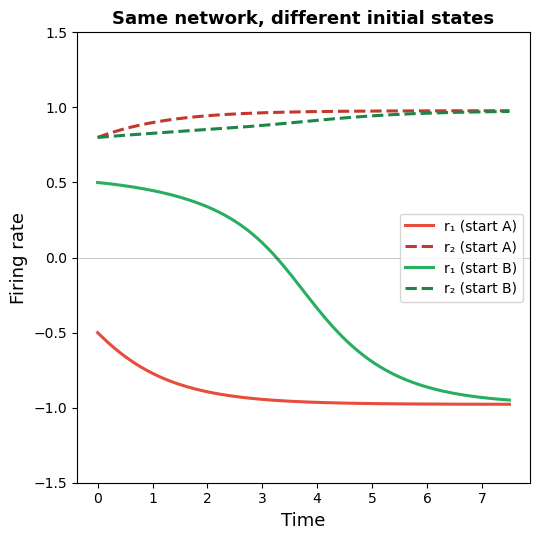

In [12]:
fig, axes = plt.subplots(1, 1, figsize=(5.5, 5.5))


# ── Time series ──────────────────────────────────────────────────────────────
ax2 = axes
inits = [[-1.0, 0.3], [0.9, -0.8]]
inits = [[-.5, 0.3], [.5, .3]]
inits = [[-.5, 0.8], [.5, .8]]
cols  = [['#e74c3c','#c0392b'], ['#27ae60','#1e8449']]
for r0, col in zip(inits, cols):
    traj = simulate(r0)
    t = np.arange(len(traj)) * 0.05
    lbl = 'A' if r0[0] < 0 else 'B'
    ax2.plot(t, traj[:,0], color=col[0], lw=2.2, label=f'r₁ (start {lbl})')
    ax2.plot(t, traj[:,1], color=col[1], lw=2.2, ls='--', label=f'r₂ (start {lbl})')

ax2.set_xlabel('Time', fontsize=13)
ax2.set_ylabel('Firing rate', fontsize=13)
ax2.set_title('Same network, different initial states', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.axhline(0, color='k', lw=0.5, alpha=0.3)
ax2.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()


## Phase portrait 
The **phase portrait** (left) shows the full state space: every point is a possible (r₁, r₂) state, and the arrows show where the network moves from there.

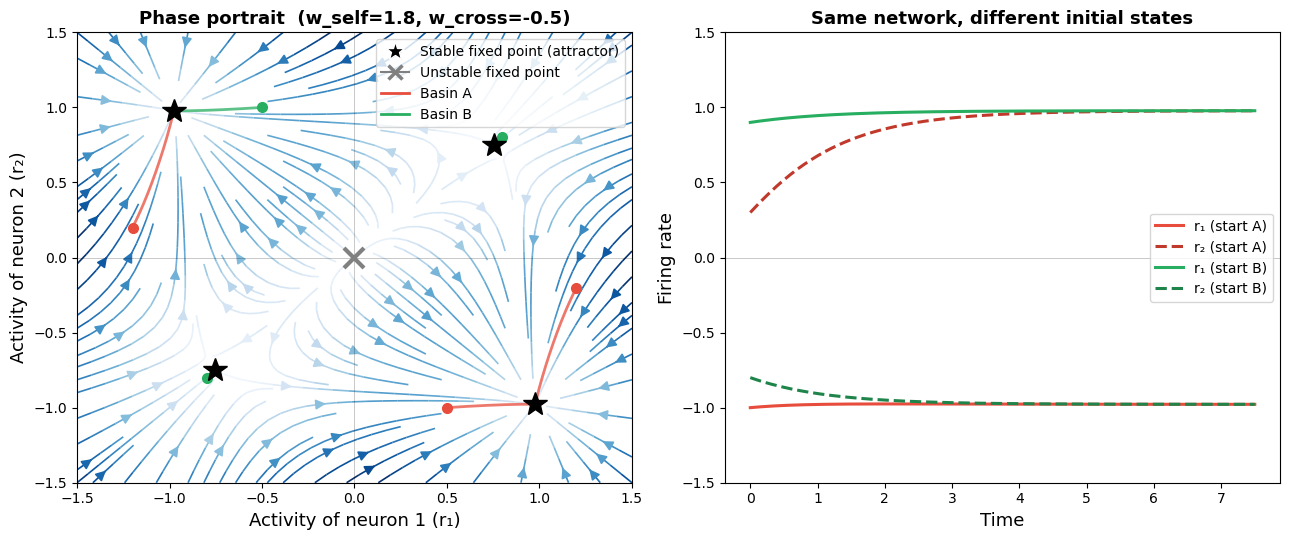


Fixed points found: 5  (4 stable, 1 unstable)


In [6]:

# ── Phase portrait ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
ax = axes[0]

r_vals = np.linspace(-1.5, 1.5, 25)
R1, R2 = np.meshgrid(r_vals, r_vals)
dR1, dR2 = np.zeros_like(R1), np.zeros_like(R2)
for i in range(R1.shape[0]):
    for j in range(R1.shape[1]):
        d = drdt(np.array([R1[i,j], R2[i,j]]))
        dR1[i,j], dR2[i,j] = d[0], d[1]

speed = np.sqrt(dR1**2 + dR2**2)
ax.streamplot(R1, R2, dR1, dR2, color=speed, cmap='Blues',
              linewidth=1.2, density=1.2, arrowsize=1.5)

# Trajectories from several starting points
starts       = [[-1.2, 0.2], [1.2, -0.2], [0.5, -1.0],
                [-0.8, -0.8], [0.8, 0.8],  [-0.5, 1.0]]
traj_colors  = ['#e74c3c','#e74c3c','#e74c3c',
                '#27ae60','#27ae60','#27ae60']
for r0, col in zip(starts, traj_colors):
    traj = simulate(r0)
    ax.plot(traj[:,0], traj[:,1], color=col, lw=2, alpha=0.75)
    ax.plot(traj[0,0], traj[0,1], 'o', color=col, ms=7, zorder=5)

# Fixed points
fps = find_fixed_points()
for fp, stable in fps:
    if stable:
        ax.plot(fp[0], fp[1], '*', color='black', ms=18, zorder=6)
    else:
        ax.plot(fp[0], fp[1], 'x', color='gray', ms=14, mew=3, zorder=6)

ax.set_xlabel('Activity of neuron 1 (r₁)', fontsize=13)
ax.set_ylabel('Activity of neuron 2 (r₂)', fontsize=13)
ax.set_title(f'Phase portrait  (w_self={w_self}, w_cross={w_cross})',
             fontsize=13, fontweight='bold')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.axvline(0, color='k', lw=0.5, alpha=0.3)
legend_elements = [
    Line2D([0],[0], marker='*', color='w', markerfacecolor='black',
           ms=14, label='Stable fixed point (attractor)'),
    Line2D([0],[0], marker='x', color='gray', ms=10, mew=2.5,
           label='Unstable fixed point'),
    Line2D([0],[0], color='#e74c3c', lw=2, label='Basin A'),
    Line2D([0],[0], color='#27ae60', lw=2, label='Basin B'),
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

# ── Time series ──────────────────────────────────────────────────────────────
ax2 = axes[1]
inits = [[-1.0, 0.3], [0.9, -0.8]]
cols  = [['#e74c3c','#c0392b'], ['#27ae60','#1e8449']]
for r0, col in zip(inits, cols):
    traj = simulate(r0)
    t = np.arange(len(traj)) * 0.05
    lbl = 'A' if r0[0] < 0 else 'B'
    ax2.plot(t, traj[:,0], color=col[0], lw=2.2, label=f'r₁ (start {lbl})')
    ax2.plot(t, traj[:,1], color=col[1], lw=2.2, ls='--', label=f'r₂ (start {lbl})')

ax2.set_xlabel('Time', fontsize=13)
ax2.set_ylabel('Firing rate', fontsize=13)
ax2.set_title('Same network, different initial states', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.axhline(0, color='k', lw=0.5, alpha=0.3)
ax2.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

n_stable = sum(1 for _, s in fps if s)
n_unstable = sum(1 for _, s in fps if not s)
print(f"\nFixed points found: {len(fps)}  ({n_stable} stable, {n_unstable} unstable)")

## Things to try

Go back to the first code cell, change the weights, and re-run everything.

| Experiment | What to set | What to expect |
|---|---|---|
| **Weak self-excitation** | `w_self = 1.0` | Only one fixed point at origin — no attractors, activity decays to 0 |
| **Strong self-excitation** | `w_self = 2.5` | Attractors move further apart (more extreme firing rates) |
| **No inhibition** | `w_cross = 0.0` | Both neurons fire together — symmetric attractors along the diagonal |
| **Excitatory cross-coupling** | `w_cross = +0.5` | Neurons tend to synchronize rather than compete |
| **Strong inhibition** | `w_cross = -1.5` | Winner-take-all dynamics — one neuron fully suppresses the other |
| **Slow time constant** | `tau = 3.0` | Same attractors, but network settles more slowly |

**Discussion question**: What does the number of stable fixed points tell us about WM capacity?

---

## Where do fixed points come from? A 1-neuron warm-up

Before looking at the full 2-neuron phase portrait, it helps to understand fixed points in one dimension first.

For a single neuron with self-weight $w$, the dynamics are:

$$\tau \frac{dr}{dt} = -r + \tanh(wr)$$

A **fixed point** $r^*$ is where $\frac{dr}{dt} = 0$, i.e., where $r^* = \tanh(w r^*)$.

Graphically: find where the line $y = r$ crosses the curve $y = \tanh(wr)$.

**Try changing `w_1d` below** to see how the number and position of fixed points changes.

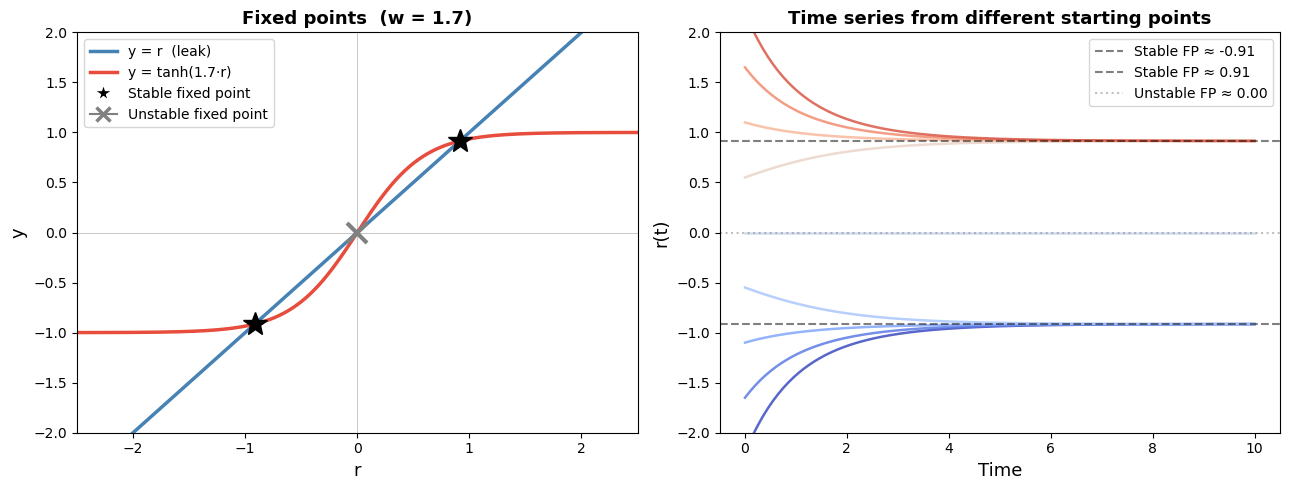


w = 1.7
  Stable fixed points:   ['-0.915', '0.915']
  Unstable fixed points: ['0.000']

  → Memory possible (≥2 stable states)


In [15]:
# ─────────────────────────────────────────
#  TWEAK THIS
# ─────────────────────────────────────────
w_1d = 1.7   # self-weight  (try: 0.5, 1.0, 1.001, 1.5, 2.5, 3.0)

# ── 1D fixed-point plot ──────────────────────────────────────────────────────
r = np.linspace(-2.5, 2.5, 500)
tanh_wr = np.tanh(w_1d * r)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: graphical solution
ax = axes[0]
ax.plot(r, r,        color='steelblue', lw=2.5, label='y = r  (leak line)')
ax.plot(r, tanh_wr,  color='#e74c3c',   lw=2.5, label=f'y = tanh({w_1d}·r)  (recurrent drive)')

# Find and classify fixed points
diff = r - tanh_wr
crossings = np.where(np.diff(np.sign(diff)))[0]
stable_fps, unstable_fps = [], []
for c in crossings:
    fp = r[c] - diff[c] * (r[c+1] - r[c]) / (diff[c+1] - diff[c])
    # stability: d/dr[-r + tanh(wr)] at fp = -1 + w*sech^2(w*fp)
    eig = -1 + w_1d / np.cosh(w_1d * fp)**2
    if eig < 0:
        stable_fps.append(fp)
        ax.plot(fp, fp, '*', color='black', ms=18, zorder=5)
    else:
        unstable_fps.append(fp)
        ax.plot(fp, fp, 'x', color='gray',  ms=14, mew=3, zorder=5)

ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.axvline(0, color='k', lw=0.5, alpha=0.3)
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2, 2)
ax.set_xlabel('r', fontsize=13); ax.set_ylabel('y', fontsize=13)
ax.set_title(f'Fixed points  (w = {w_1d})', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color='steelblue', lw=2.5, label='y = r  (leak)'),
    Line2D([0],[0], color='#e74c3c',   lw=2.5, label=f'y = tanh({w_1d}·r)'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor='black', ms=13, label='Stable fixed point'),
    Line2D([0],[0], marker='x', color='gray', ms=10, mew=2.5, label='Unstable fixed point'),
], fontsize=10)

# Right: time series from several starting points
ax2 = axes[1]
dt, T = 0.05, 200
starts = np.linspace(-2.2, 2.2, 9)
cmap = plt.cm.coolwarm
for i, r0 in enumerate(starts):
    rv = r0
    traj = [rv]
    for _ in range(T):
        rv = rv + dt * (-rv + np.tanh(w_1d * rv))
        traj.append(rv)
    traj = np.array(traj)
    t = np.arange(len(traj)) * dt
    ax2.plot(t, traj, color=cmap(i / len(starts)), lw=1.8, alpha=0.85)

for fp in stable_fps:
    ax2.axhline(fp, color='black', lw=1.5, ls='--', alpha=0.5, label=f'Stable FP ≈ {fp:.2f}')
for fp in unstable_fps:
    ax2.axhline(fp, color='gray',  lw=1.5, ls=':',  alpha=0.5, label=f'Unstable FP ≈ {fp:.2f}')

ax2.set_xlabel('Time', fontsize=13); ax2.set_ylabel('r(t)', fontsize=13)
ax2.set_title('Time series from different starting points', fontsize=13, fontweight='bold')
ax2.set_ylim(-2, 2)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nw = {w_1d}")
print(f"  Stable fixed points:   {[f'{fp:.3f}' for fp in stable_fps]}")
print(f"  Unstable fixed points: {[f'{fp:.3f}' for fp in unstable_fps]}")
print(f"\n  → {'Memory possible (≥2 stable states)' if len(stable_fps) >= 2 else 'No memory — only one stable state (r=0)'}")

### What to notice

- At **w = 0.5** (< 1): only one fixed point at r = 0. All trajectories decay to zero — no memory.
- At **w = 1.0** (= 1): the bifurcation point — the curve is just tangent to the line at the origin. One fixed point, but barely stable.
- At **w = 1.001**: two new stable fixed points appear almost from nothing. This is the **bifurcation** — the moment memory becomes possible.
- At **w = 1.8**: two clear stable attractors at ±r*, one unstable fixed point at 0. Starting above 0 → settles at +r*; starting below → settles at −r*.
- At **w = 3.0**: attractors move even further from zero (stronger self-excitation → more extreme stable states).

**Connection to the 2-neuron network**: `w_self` in the earlier cells plays the same role as `w_1d` here — it controls whether the network has stable attractor states at all. The cross-inhibition `w_cross` then breaks the symmetry and determines *which* neuron wins.